# Car Damage Prediction

In [1]:
# Importing Libraries 
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
import time 
import torchvision.models as models 
from matplotlib import pyplot as plt 


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Load Data

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
dataset_path = r"C:\Users\pksju\Desktop\code\Car_damage_prediction\dataset"

dataset = datasets.ImageFolder(dataset_path, transform=image_transforms)
len(dataset)

2296

In [5]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
2296*0.75

1722.0

In [9]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size
train_size, val_size

(1722, 574)

In [10]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [12]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [13]:
labels[6]

tensor(3)

In [14]:
images[6].shape

torch.Size([3, 224, 224])

In [15]:
images[6].permute(1, 2, 0).shape  

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.535425].


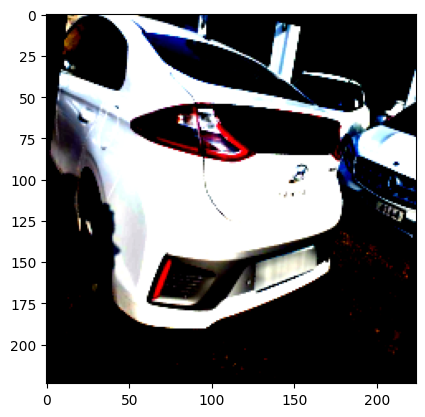

In [16]:
plt.imshow(images[6].permute(1, 2, 0)) # Re-arranging dimension to display the image 
plt.show()

### Model 1: CNN

In [17]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=1, stride=1, padding=1), #  (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16,112,112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [18]:
# Instantiate the model, Loss function, and optimzer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
len(train_loader.dataset)

1722

In [20]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")


            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f" => Validation Accuracy: {100 * correct / total:.2f}% <=")

    end = time.time()
    print(f"Execution time: {end - start} seconds")
    return all_labels, all_predictions

In [22]:
train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.10
Batch: 20, Epoch: 1, Loss: 1.22
Batch: 30, Epoch: 1, Loss: 1.26
Batch: 40, Epoch: 1, Loss: 1.19
Batch: 50, Epoch: 1, Loss: 0.98
Epoch [1/5], Avg Loss: 1.1360
 => Validation Accuracy: 52.96% <=
Batch: 10, Epoch: 2, Loss: 1.13
Batch: 20, Epoch: 2, Loss: 0.78
Batch: 30, Epoch: 2, Loss: 1.02
Batch: 40, Epoch: 2, Loss: 0.71
Batch: 50, Epoch: 2, Loss: 0.96
Epoch [2/5], Avg Loss: 0.9944
 => Validation Accuracy: 56.62% <=
Batch: 10, Epoch: 3, Loss: 1.03
Batch: 20, Epoch: 3, Loss: 1.09
Batch: 30, Epoch: 3, Loss: 1.00
Batch: 40, Epoch: 3, Loss: 0.77
Batch: 50, Epoch: 3, Loss: 0.69
Epoch [3/5], Avg Loss: 0.9286
 => Validation Accuracy: 55.57% <=
Batch: 10, Epoch: 4, Loss: 0.85
Batch: 20, Epoch: 4, Loss: 1.06
Batch: 30, Epoch: 4, Loss: 0.95
Batch: 40, Epoch: 4, Loss: 0.75
Batch: 50, Epoch: 4, Loss: 1.08
Epoch [4/5], Avg Loss: 0.8591
 => Validation Accuracy: 56.97% <=
Batch: 10, Epoch: 5, Loss: 0.78
Batch: 20, Epoch: 5, Loss: 0.95
Batch: 30, Epoch: 5, Loss: 0.92
Batc

([np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(4),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(5),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(3),
  np.int64(5),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(5),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(2),
  np.int64

we can observe from the loss at each batch and validation accuracy that ==> The above model has overfitted

### Model 2: CNN with Regularization

In [24]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=1, stride=1, padding=1), #  (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16,112,112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28)
            
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [26]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 14.75
Batch: 20, Epoch: 1, Loss: 7.04
Batch: 30, Epoch: 1, Loss: 2.34
Batch: 40, Epoch: 1, Loss: 1.65
Batch: 50, Epoch: 1, Loss: 1.71
Epoch [1/10], Avg Loss: 8.0966
 => Validation Accuracy: 36.06% <=
Batch: 10, Epoch: 2, Loss: 1.57
Batch: 20, Epoch: 2, Loss: 1.46
Batch: 30, Epoch: 2, Loss: 1.61
Batch: 40, Epoch: 2, Loss: 1.49
Batch: 50, Epoch: 2, Loss: 1.93
Epoch [2/10], Avg Loss: 1.5882
 => Validation Accuracy: 41.29% <=
Batch: 10, Epoch: 3, Loss: 1.38
Batch: 20, Epoch: 3, Loss: 1.42
Batch: 30, Epoch: 3, Loss: 1.55
Batch: 40, Epoch: 3, Loss: 1.51
Batch: 50, Epoch: 3, Loss: 1.55
Epoch [3/10], Avg Loss: 1.5032
 => Validation Accuracy: 48.43% <=
Batch: 10, Epoch: 4, Loss: 1.53
Batch: 20, Epoch: 4, Loss: 1.55
Batch: 30, Epoch: 4, Loss: 1.39
Batch: 40, Epoch: 4, Loss: 1.37
Batch: 50, Epoch: 4, Loss: 1.46
Epoch [4/10], Avg Loss: 1.4349
 => Validation Accuracy: 50.87% <=
Batch: 10, Epoch: 5, Loss: 1.25
Batch: 20, Epoch: 5, Loss: 1.70
Batch: 30, Epoch: 5, Loss: 1.54

([np.int64(3),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(5),
  np.int64(3),
  np.int64(4),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(4),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(4),
  np.int64(3),
  np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64

After doing regularization in updated model above, still there is not much improvement in validation accuracy.
The model has not trained well likely due to less number of images in dataset. So, I am now going to use concept of Transfer Learning in the model

### Model 3: Transfer Learning with EfficientNet

In [ ]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        # since wdk that how many in-features are there to FCN in pre-built model that get trained on ImageNet dataset 
        in_features = self.model.classifier[1].in_features


        # To update lastly FCN (Fully Connected network) ==> model.classifier
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)

        )

    def forward(self, x):
        x = self.model(x)
        return x
        

In [28]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

train_model(model, criterion, optimizer, epochs=5)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\pksju/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Batch: 10, Epoch: 1, Loss: 1.63
Batch: 20, Epoch: 1, Loss: 1.49
Batch: 30, Epoch: 1, Loss: 1.43
Batch: 40, Epoch: 1, Loss: 1.45
Batch: 50, Epoch: 1, Loss: 1.24
Epoch [1/5], Avg Loss: 1.4788
 => Validation Accuracy: 59.76% <=
Batch: 10, Epoch: 2, Loss: 1.15
Batch: 20, Epoch: 2, Loss: 1.13
Batch: 30, Epoch: 2, Loss: 1.13
Batch: 40, Epoch: 2, Loss: 1.27
Batch: 50, Epoch: 2, Loss: 1.27
Epoch [2/5], Avg Loss: 1.1404
 => Validation Accuracy: 62.20% <=
Batch: 10, Epoch: 3, Loss: 0.96
Batch: 20, Epoch: 3, Loss: 1.14
Batch: 30, Epoch: 3, Loss: 1.12
Batch: 40, Epoch: 3, Loss: 1.06
Batch: 50, Epoch: 3, Loss: 0.89
Epoch [3/5], Avg Loss: 1.0186
 => Validation Accuracy: 64.46% <=
Batch: 10, Epoch: 4, Loss: 0.95
Batch: 20, Epoch: 4, Loss: 0.83
Batch: 30, Epoch: 4, Loss: 0.93
Batch: 40, Epoch: 4, Loss: 0.95
Batch: 50, Epoch: 4, Loss: 0.97
Epoch [4/5], Avg Loss: 0.9570
 => Validation Accuracy: 65.33% <=
Batch: 10, Epoch: 5, Loss: 1.21
Batch: 20, Epoch: 5, Loss: 0.80
Batch: 30, Epoch: 5, Loss: 0.83
Batc

([np.int64(2),
  np.int64(2),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(4),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(1),
  np.int64(5),
  np.int64(3),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(1),
  np.int64(3),
  np.int64(4),
  np.int64

#### EfficientNet B0 - Transfer Learning Results
- Architecture: Pretrained EfficientNet B0 with frozen layers + custom classifier
- Best Validation Accuracy: 66.55% (Epoch 5)

### Model 4: Transfer learning with RestNet

In [ ]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')

        # freeze all the layers except the final Fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        # freeze all the layers except the final Fully connected layer
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # To update lastly FCN (Fully Connected network) ==> model.classifier
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features, num_classes)

        )

    def forward(self, x):
        x = self.model(x)
        return x
        

In [30]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=5)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\pksju/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Batch: 10, Epoch: 1, Loss: 0.99
Batch: 20, Epoch: 1, Loss: 0.65
Batch: 30, Epoch: 1, Loss: 0.71
Batch: 40, Epoch: 1, Loss: 0.78
Batch: 50, Epoch: 1, Loss: 1.01
Epoch [1/5], Avg Loss: 0.8887
 => Validation Accuracy: 77.00% <=
Batch: 10, Epoch: 2, Loss: 0.57
Batch: 20, Epoch: 2, Loss: 0.57
Batch: 30, Epoch: 2, Loss: 0.57
Batch: 40, Epoch: 2, Loss: 0.42
Batch: 50, Epoch: 2, Loss: 0.46
Epoch [2/5], Avg Loss: 0.4924
 => Validation Accuracy: 81.01% <=
Batch: 10, Epoch: 3, Loss: 0.65
Batch: 20, Epoch: 3, Loss: 0.26
Batch: 30, Epoch: 3, Loss: 0.34
Batch: 40, Epoch: 3, Loss: 0.70
Batch: 50, Epoch: 3, Loss: 0.23
Epoch [3/5], Avg Loss: 0.3564
 => Validation Accuracy: 82.58% <=
Batch: 10, Epoch: 4, Loss: 0.20
Batch: 20, Epoch: 4, Loss: 0.27
Batch: 30, Epoch: 4, Loss: 0.29
Batch: 40, Epoch: 4, Loss: 0.19
Batch: 50, Epoch: 4, Loss: 0.43
Epoch [4/5], Avg Loss: 0.2591
 => Validation Accuracy: 80.66% <=
Batch: 10, Epoch: 5, Loss: 0.14
Batch: 20, Epoch: 5, Loss: 0.10
Batch: 30, Epoch: 5, Loss: 0.14
Batc

#### ResNet50 - Transfer Learning Results
- Pretrained ResNet50 with layer4 unfrozen + custom classifier
- Best Validation Accuracy: 82.58% (Epoch 3)
- Significantly better than EfficientNet because layer4 was
  unfrozen allowing the model to fine-tune deeper features specific
  to car damage detection.

##### I ran hyperparameter tunning in another notebook and figured that the best parameters for resnet models are 
##### (1) Dropout rate = 0.4
##### (2) Learning Rate = 0.0005

So now let's train the model once again with these best parameters 

In [34]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

labels, predictions = train_model(model, criterion, optimizer, epochs=5)

Batch: 10, Epoch: 1, Loss: 1.26
Batch: 20, Epoch: 1, Loss: 0.87
Batch: 30, Epoch: 1, Loss: 0.61
Batch: 40, Epoch: 1, Loss: 0.82
Batch: 50, Epoch: 1, Loss: 0.79
Epoch [1/5], Avg Loss: 0.9944
 => Validation Accuracy: 74.56% <=
Batch: 10, Epoch: 2, Loss: 0.47
Batch: 20, Epoch: 2, Loss: 0.51
Batch: 30, Epoch: 2, Loss: 0.55
Batch: 40, Epoch: 2, Loss: 0.51
Batch: 50, Epoch: 2, Loss: 0.40
Epoch [2/5], Avg Loss: 0.4849
 => Validation Accuracy: 76.66% <=
Batch: 10, Epoch: 3, Loss: 0.42
Batch: 20, Epoch: 3, Loss: 0.17
Batch: 30, Epoch: 3, Loss: 0.40
Batch: 40, Epoch: 3, Loss: 0.61
Batch: 50, Epoch: 3, Loss: 0.25
Epoch [3/5], Avg Loss: 0.3153
 => Validation Accuracy: 79.97% <=
Batch: 10, Epoch: 4, Loss: 0.22
Batch: 20, Epoch: 4, Loss: 0.34
Batch: 30, Epoch: 4, Loss: 0.18
Batch: 40, Epoch: 4, Loss: 0.30
Batch: 50, Epoch: 4, Loss: 0.28
Epoch [4/5], Avg Loss: 0.2156
 => Validation Accuracy: 82.75% <=
Batch: 10, Epoch: 5, Loss: 0.23
Batch: 20, Epoch: 5, Loss: 0.38
Batch: 30, Epoch: 5, Loss: 0.18
Batc

#### ResNet50 - After Hyperparameter Tuning (Optuna)
Best params: lr=0.0005, dropout=0.4 → Best Accuracy: 82.75%
Marginal improvement over previous run (82.58%), model has 
plateaued.

In [35]:
# Save the trained model
torch.save(model.state_dict(), "saved_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [36]:
model = CarClassifierResNet(num_classes=num_classes)
model.load_state_dict(torch.load("saved_model.pth"))
model.eval()
print("Model loaded successfully!")

Model loaded successfully!
